<a href="https://colab.research.google.com/github/MSGamgee85/MSGamgee85/blob/main/EGF_08_Lista_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## **Exercício 1**
---

### **Função Objetivo**:

$min \, w = \sum_{i=1}^4 \, 400x_i+450y_i+20z_i $

$min \, w = 400x_1 + 400x_2 + 400x_3 + 400x_4 + 450y_1 + 450y_2 + 450y_3 + 450y_4 + 20z_1 + 20z_2 + 20z_3 + 20z_4$

### **Restrições**:

$s.a. \begin{cases}
x_1 + y_1 - z_1 = 30 \\
x_2 + y_2 + z_1 - z_2 = 60 \\
x_3 + y_3 + z_2 - z_3 = 75 \\
x_4 + y_4 + z_3 - z_4 = 25 \\
x_i \leq 40 \quad i =1,2,3,4 \\
x_i \geq 0, \quad y_i \geq 0 \quad z_i \geq 0 \quad i =1,2,3,4 \\
x_i, y_i, z_i \in Z^{+} \\
\end{cases}$

In [57]:
# Bibliotecas utilizadas
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

In [85]:
# Coeficientes da função objetivo
c = [400, 400, 400, 400, # [x1, x2, x3, x4]
     450, 450, 450, 450, # [y1, y2, y3, y4]
     20, 20, 20, 20]     # [z1, z2, z3, z4]

# Coeficientes das restrições
# Restrição 1: x1 + y1 - z1 = 30
# Restrição 2: x2 + y2 + z1 - z2 = 60
# Restrição 3: x3 + y3 + z2 - z3 = 75
# Restrição 4: x4 + y4 + z3 - z4 = 25
A_eq = [
    [1, 0, 0, 0, 1, 0, 0, 0, -1, 0, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 0, 1, -1, 0, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 1, -1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, -1]
]

# Limites das restrições
b_eq = [30, 60, 75, 25]

# Limites das variáveis
bounds = [
    (0, 40),  # x1
    (0, 40),  # x2
    (0, 40),  # x3
    (0, 40),  # x4
    (0, None), # y1
    (0, None), # y2
    (0, None), # y3
    (0, None), # y4
    (0, None), # z1
    (0, None), # z2
    (0, None), # z3
    (0, None)  # z4
]

# Resolvendo o problema de minimização
res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='simplex')

# Resultado
print('Valor ótimo:', res.fun)
print('Solução ótima (x1, x2, x3, x4, y1, y2, y3, y4, z1, z2, z3, z4):', res.x)

Valor ótimo: 78450.0
Solução ótima (x1, x2, x3, x4, y1, y2, y3, y4, z1, z2, z3, z4): [40. 40. 40. 25.  0. 10. 35.  0. 10.  0.  0.  0.]


/tmp/ipython-input-2564041029.py:42: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='simplex')


## **Exercício 2**
---

### **Item (a)**

### **Função objetivo**
---
$ {max \ z}  = 5x_1 + 3x_2 \implies \boxed{min \, (-z) = -5x_1 - 3x_2}$

### **Restrições**

$s.a. \begin{cases}
3x_1 + 5x_2 \leq 15 \\
5x_1 + 2x_2 \leq 10 \\
x_1, x_2 \geq 0
\end{cases}$

In [7]:
# ----------------- #
# Solução analítica #
# ----------------- #

# Coeficientes da função objetivo (queremos maximizar, então colocamos o sinal negativo)
c = [-5, -3]

# Coeficientes das restrições
A = [[3, 5],
     [5, 2]]

# Limites das restrições
b = [15, 10]

# Limites das variáveis (x1, x2 >= 0)
bounds = [(0, None), (0, None)]

# Resolvendo o problema de maximização
res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='HiGHS')

# Resultado
print('Valor ótimo:', f'({-res.fun:.2f})')  # Função objetivo foi negada, então negamos novamente
print('Solução ótima (x1, x2):', f'({res.x[0]:.2f}, {res.x[1]:.2f})')

# --------------------------------------------------------------------------- #
# Note que o método simplex foi descontinuado em versões mais atuais do scipy #
# sendo substituído pelo método HiGHS                                         #
# --------------------------------------------------------------------------- #

Valor ótimo: (12.37)
Solução ótima (x1, x2): (1.05, 2.37)


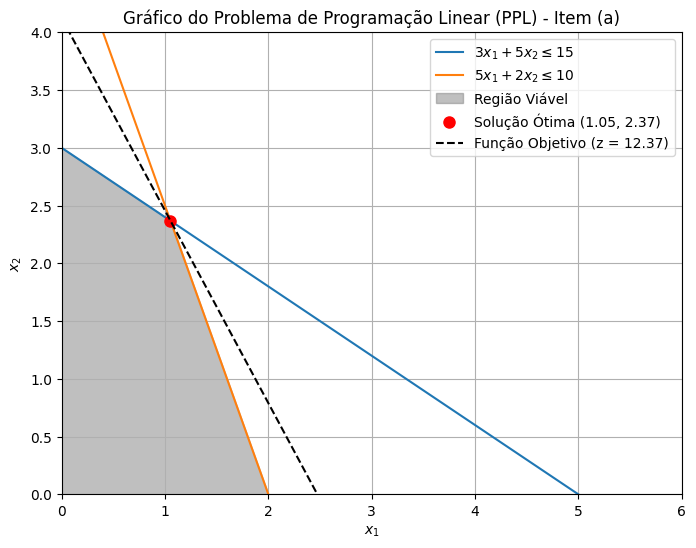

In [8]:
# --------------- #
# Solução gráfica #
# --------------- #

"""
# Restrição 1: 3x1 + 5x2 <= 15  => x2 <= (15 - 3x1) / 5
# Restrição 2: 5x1 + 2x2 <= 10  => x2 <= (10 - 5x1) / 2
# x1 >= 0, x2 >= 0
"""

# Define as equações das restrições
x1 = np.linspace(0, 5, 400) # gera 400 pontos entre x = 0 e x = 5 [ideal para plotar gráficos]
r1 = (15 - 3 * x1) / 5      # restrição 1
r2 = (10 - 5 * x1) / 2      # restrição 2

# Gera os gráficos das restrições
plt.figure(figsize=(8, 6))
plt.plot(x1, r1, label=r'$3x_1 + 5x_2 \leq 15$')
plt.plot(x1, r2, label=r'$5x_1 + 2x_2 \leq 10$')

# Hachura a região viável, abaixo das duas retas das restrições no primeiro quadrante (x1>=0, x2>=0)
plt.fill_between(x1, 0, np.minimum(r1, r2),
                 where=(x1 >= 0) & (np.minimum(r1, r2) >= 0),
                 color='grey', alpha=0.5, label='Região Viável')

# Plota a solução ótima obtida anteriormente
x1_otimo = 1.05
x2_otimo = 2.37
plt.plot(x1_otimo, x2_otimo, 'ro', markersize=8,
         label=f'Solução Ótima ({x1_otimo:.2f}, {x2_otimo:.2f})')


# Gera a curva da função objetivo
# z = 5x1 + 3x2 => x2 = (z - 5x1) / 3
z_otimo = 12.37
funcao_obj = (z_otimo - 5 * x1) / 3
plt.plot(x1, funcao_obj, 'k--', label=f'Função Objetivo (z = {z_otimo:.2f})')

# Gera a figura
plt.xlim(0, 6) # intervalo do eixo x
plt.ylim(0, 4) # intervalo do eixo y
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Gráfico do Problema de Programação Linear (PPL) - Item (a)')
plt.legend()
plt.grid(True)
plt.show()

### **Item (b)**

### **Função objetivo**
---
$ min \, z  = 5x_1 + x_2$

### **Restrições**

$s.a. \begin{cases}
3x_1 + 5x_2 \leq 15 \\
5x_1 + 2x_2 \leq 10 \\
x_1, x_2 \geq 0
\end{cases}$

In [9]:
# ----------------- #
# Solução analítica #
# ----------------- #

# Coeficientes da função objetivo
c = [5, 1]

# Coeficientes das restrições
A = [[3, 5],
     [5, 2]]

# Limites das restrições
b = [15, 10]

# Limites das variáveis (x1, x2 >= 0)
bounds = [(0, None), (0, None)]

# Resolvendo o problema de maximização
res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='HiGHS')

# Resultado
print('Valor ótimo:', f'({res.fun:.2f})')
print('Solução ótima (x1, x2):', f'({res.x[0]:.2f}, {res.x[1]:.2f})')

Valor ótimo: (0.00)
Solução ótima (x1, x2): (0.00, 0.00)


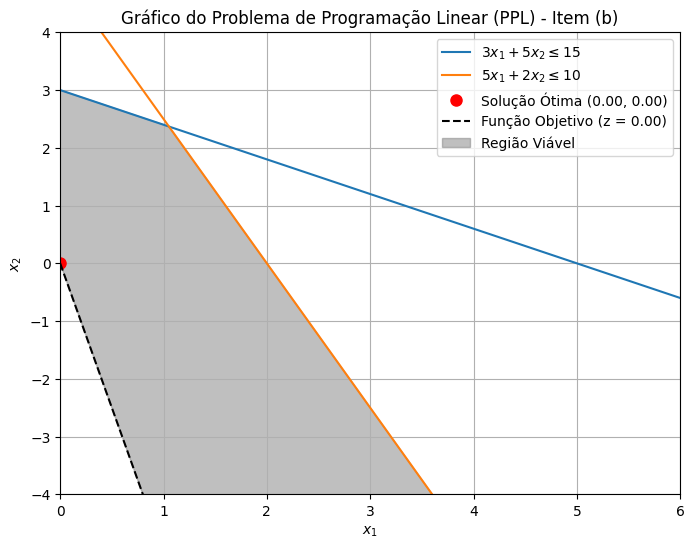

In [10]:
# --------------- #
# Solução gráfica #
# --------------- #

"""

# Restrição 1: 3x1 + 5x2 <= 15  => x2 <= (15 - 3x1) / 5
# Restrição 2: 5x1 + 2x2 <= 10  => x2 <= (10 - 5x1) / 2
# x1 >= 0, x2 >= 0

"""

# Define as equações das restrições
x1 = np.linspace(0, 6, 500) # gera 400 pontos entre x = 0 e x = 5 [ideal para plotar gráficos]
r1 = (15 - 3 * x1) / 5   # restrição 1
r2 = (10 - 5 * x1) / 2   # restrição 2

# Gera os gráficos das restrições
plt.figure(figsize=(8, 6))
plt.plot(x1, r1, label=r'$3x_1 + 5x_2 \leq 15$')
plt.plot(x1, r2, label=r'$5x_1 + 2x_2 \leq 10$')

# Plota a solução ótima obtida anteriormente
x1_otimo = 0.00
x2_otimo = 0.00
plt.plot(x1_otimo, x2_otimo, 'ro', markersize=8,
         label=f'Solução Ótima ({x1_otimo:.2f}, {x2_otimo:.2f})')

# Gera a curva da função objetivo
# z = 5x1 + x2 => x2 = z - 5x1
z_otimo = 0.00
funcao_obj = (z_otimo - 5 * x1)
plt.plot(x1, funcao_obj, 'k--', label=f'Função Objetivo (z = {z_otimo:.2f})')

# Hachura a região viável
plt.fill_between(x1, funcao_obj, np.minimum(r1, r2),
                 where=(x1 >= 0) & (np.minimum(r1, r2) >= -4),
                 color='grey', alpha=0.5, label='Região Viável')

# Gera a figura
plt.xlim(0, 6) # intervalo do eixo x
plt.ylim(-4, 4) # intervalo do eixo y
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Gráfico do Problema de Programação Linear (PPL) - Item (b)')
plt.legend()
plt.grid(True)
plt.show()

### **Item (c)**

### **Função objetivo**
---
$ max \, z  = 2x_1 + 3x_2$

### **Restrições**

$s.a. \begin{cases}
x_1 + x_2 \leq 4 \\
6x_1 + 2x_2 \geq 8 \\
x_1 + 5x_2 \geq 4 \\
0 \leq x_1 \leq 3 \\
0 \leq x_2 \leq 3
\end{cases}$

In [11]:
# ----------------- #
# Solução analítica #
# ----------------- #

# Coeficientes da função objetivo [queremos maximizar então trocamos o sinal]
c = [-2, -3]

# Coeficientes das restrições
A = [[1, 1],
     [-6, -2],
     [-1, -5]]

# Limites das restrições
b = [4, -8, -4]

# Limites das variáveis ( 0 =< x1, x2 =< 3 )
bounds = [(0, 3), (0, 3)]

# Resolvendo o problema de maximização
res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='HiGHS')

# Resultado
print('Valor ótimo:', f'({-res.fun:.2f})') # devemos negar novamente pois função objetivo foi negada
print('Solução ótima (x1, x2):', f'({res.x[0]:.2f}, {res.x[1]:.2f})')

Valor ótimo: (11.00)
Solução ótima (x1, x2): (1.00, 3.00)


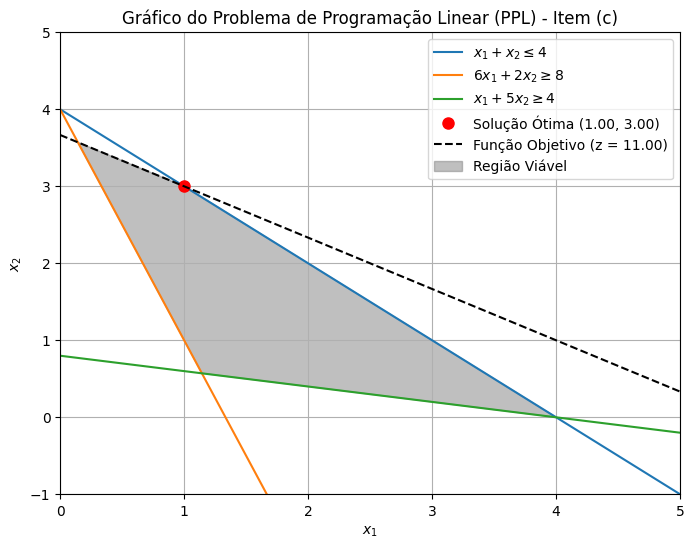

In [73]:
# --------------- #
# Solução gráfica #
# --------------- #

"""
# Restrição 1: x1 + x2 <= 4  ⇒  x2 <= 4 - x1
# Restrição 2: 6x1 + 2x2 >= 8 ⇒ 2x2 >= 8 - 6x1 ⇒ x2 >= (8 - 6x1) / 2
# Restrição 3: x1 + 5x2 >= 4 ⇒ 5x2 >= 4 - x1 ⇒ x2 >= (4 - x1) / 5
# x1, x2 >= 0
# 0 <= x1 <= 3
# 0 <= x2 <= 3

"""

# Define as equações das restrições
x1 = np.linspace(0, 5, 400) # gera 400 pontos entre x = 0 e x = 5 [ideal para plotar gráficos]
r1 = 4 - x1                 # restrição 1 (<=)
r2 = (8 - 6 * x1) / 2       # restrição 2 (>=)
r3 = (4 - x1) / 5           # restrição 3 (>=)

# Gera os gráficos das restrições
plt.figure(figsize=(8, 6))
plt.plot(x1, r1, label=r'$x_1 + x_2 \leq 4$')
plt.plot(x1, r2, label=r'$6x_1 + 2x_2 \geq 8$')
plt.plot(x1, r3, label=r'$x_1 + 5x_2 \geq 4$')

# Plota a solução ótima obtida anteriormente
x1_otimo = 1.00
x2_otimo = 3.00
plt.plot(x1_otimo, x2_otimo, 'ro', markersize=8,
         label=f'Solução Ótima ({x1_otimo:.2f}, {x2_otimo:.2f})')

# Gera a curva da função objetivo
# z = 2x1 + 3x2 => x2 = (z - 2x1) / 3
z_otimo = 11.00
funcao_obj = (z_otimo - 2 * x1) / 3
plt.plot(x1, funcao_obj, 'k--', label=f'Função Objetivo (z = {z_otimo:.2f})')

# Hachura a região viável
x_coord = [1, 1/7, 8/7, 4]   # coordenadas x dos vértices do polígono
y_coord = [3, 25/7, 4/7, 0]  # coordenadas y dos vértices do polígono
plt.fill(x_coord, y_coord, color='grey', alpha=0.5, label='Região Viável')

# Gera a figura
plt.xlim(0, 5) # intervalo do eixo x
plt.ylim(-1, 5) # intervalo do eixo y
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Gráfico do Problema de Programação Linear (PPL) - Item (c)')
plt.legend()
plt.grid(True)
plt.show()

### **Item (d)**

### **Função objetivo**
---
$ max \, z  = 2x_1 + 2x_2$

### **Restrições**
$s.a. \begin{cases}
x_1 - 5x_2 \geq -1 \\
-0,5x_1 + x_2 \leq 2 \\
x_1, x_2 \geq 0
\end{cases}$


In [ ]:
# Coeficientes da função objetivo [queremos maximizar então trocamos o sinal]
c = [-2, -2]

# Coeficientes das restrições
A = [[-1, 5],
     [-0.5, 1]]

# Limites das restrições
b = [1, 2]

# Limites das variáveis ( x1, x2 >= 0 )
bounds = [(0, None), (0, None)]

# Resolvendo o problema de maximização
res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='HiGHS')

# Resultado
if res.success:
  print('Status:', res.message)
  print('Valor ótimo:', f'({-res.fun:.2f})') # devemos negar novamente pois função objetivo foi negada
  print('Solução ótima (x1, x2):', f'({res.x[0]:.2f}, {res.x[1]:.2f})')
else:
  print('Status:', res.message)
  print('Não foi encontrada uma solução ótima (problema pode ser ilimitado ou inviável).')

Status: The problem is unbounded. (HiGHS Status 10: model_status is Unbounded; primal_status is Feasible)
Não foi encontrada uma solução ótima (problema pode ser ilimitado ou inviável).


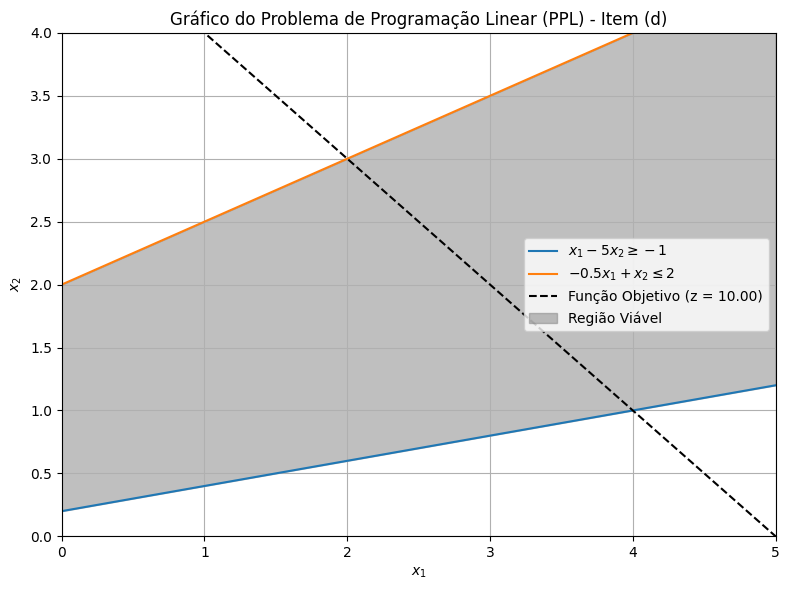

In [84]:
# --------------- #
# Solução gráfica #
# --------------- #

"""
# Restrição 1: x1  - 5x2 >= -1  => x2 <= (1 + x1) / 5
# Restrição 2: -0.5x1 + x2 <= 2  => x2 <= 2 + 0.5x1
# x1 >= 0, x2 >= 0

"""

# Define as equações das restrições
x1 = np.linspace(0, 5, 400) # gera 400 pontos entre x = 0 e x = 5 [ideal para plotar gráficos]
r1 = (1 + x1) / 5      # restrição 1
r2 = 2 + 0.5 * x1      # restrição 2

# Gera os gráficos das restrições
plt.figure(figsize=(8, 6))
plt.plot(x1, r1, label=r'$x_1 - 5x_2 \geq -1$')
plt.plot(x1, r2, label=r'$-0.5x_1 + x_2 \leq 2$')

# Gera a curva da função objetivo
# z = 2x1 + 2x2 => x2 = (z - 2x1) / 2
z_otimo = 10  # digite o valor de z
funcao_obj = (z_otimo - 2 * x1) / 2
plt.plot(x1, funcao_obj, 'k--', label=f'Função Objetivo (z = {z_otimo:.2f})')

# Hachura a região viável
plt.fill_between(x1, r1, r2,
                 color='grey', alpha=0.5, label='Região Viável')

# Gera a figura
plt.xlim(0, 5) # intervalo do eixo x
plt.ylim(0, 4) # intervalo do eixo y
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Gráfico do Problema de Programação Linear (PPL) - Item (d)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ---------------------------- #
# Temos nesse caso uma solução #
# ilimitada.                   #
# ---------------------------- #

## **Exercício 3**
---
Feito manualmente.

## **Exercício 4**
---

### **Item (a)**

### **Função objetivo**
---
$ max \, z  = 4x_1 + 5x_2 + x_3$

### **Restrições**

$s.a. \begin{cases}
3x_1 + 2x_2 \leq 10 \\
x_1 + 4x_2 \leq 11 \\
3x_1 + 3x_2 + x_3 \leq 13 \\
x_1, x_2, x_3 \geq 0
\end{cases}$

In [87]:
# ----------------- #
# Solução analítica #
# ----------------- #

# Coeficientes da função objetivo (queremos maximizar, então colocamos o sinal negativo)
c = [-4, -5, -1]

# Coeficientes das restrições
A = [[3, 2, 0],
     [1, 4, 0],
     [3, 3, 1]]

# Limites das restrições
b = [10, 11, 13]

# Limites das variáveis (x1, x2, x3 >= 0)
bounds = [(0, None), (0, None), (0, None)]

# Resolvendo o problema de maximização
res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='simplex')

# Resultado
print('Valor ótimo:', f'({-res.fun:.2f})')  # Função objetivo foi negada, então negamos novamente
print('Solução ótima (x1, x2):', f'({res.x[0]:.2f}, {res.x[1]:.2f})')

# --------------------------------------------------------------------------- #
# Note que o método simplex foi descontinuado em versões mais atuais do scipy #
# sendo substituído pelo método HiGHS                                         #
# --------------------------------------------------------------------------- #

Valor ótimo: (19.40)
Solução ótima (x1, x2): (1.80, 2.30)


/tmp/ipython-input-1076705942.py:20: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='simplex')


### **Item (b)**

### **Função objetivo**
---
$ max \, z  = x_1 - 3x_2 + 2x_3$

### **Restrições**

$s.a. \begin{cases}
3x_1 - x_2 + 2x_3 \leq 7 \\
-2x_1 + 4x_2 \leq 12 \\
-4x_1 + 3x_2 + 8x_3 \leq 10 \\
x_1, x_2, x_3 \geq 0
\end{cases}$

In [88]:
# ----------------- #
# Solução analítica #
# ----------------- #

# Coeficientes da função objetivo (queremos maximizar, então colocamos o sinal negativo)
c = [-1, 3, -2]

# Coeficientes das restrições
A = [[3, -1, 2],
     [-2, 4, 0],
     [-4, 3, 8]]

# Limites das restrições
b = [7, 12, 10]

# Limites das variáveis (x1, x2, x3 >= 0)
bounds = [(0, None), (0, None), (0, None)]

# Resolvendo o problema de maximização
res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

# Resultado
print('Valor ótimo:', f'({-res.fun:.2f})')  # Função objetivo foi negada, então negamos novamente
print('Solução ótima (x1, x2):', f'({res.x[0]:.2f}, {res.x[1]:.2f})')

# --------------------------------------------------------------------------- #
# Note que o método simplex foi descontinuado em versões mais atuais do scipy #
# sendo substituído pelo método HiGHS                                         #
# --------------------------------------------------------------------------- #

Valor ótimo: (4.75)
Solução ótima (x1, x2): (1.12, 0.00)
